In [ ]:
# --- portable setup (added 2026-09-12 when the project moved to GitHub) ---------------------
# All paths below resolve from HME_ROOT, the repository root.  On Colab: mount Drive and point
# HME_ROOT at your clone.  Locally: run jupyter from the repo, or export HME_ROOT=/path/to/repo.
import os
try:
    from google.colab import drive; drive.mount('/content/drive')
    HME_ROOT = os.environ.get('HME_ROOT', '/content/drive/MyDrive/hyperbolic-icd10')   # <-- edit
except ImportError:
    HME_ROOT = os.environ.get('HME_ROOT', os.path.abspath(os.path.join(os.getcwd(), '..')))
assert os.path.isdir(os.path.join(HME_ROOT, 'data')), f'HME_ROOT={HME_ROOT!r} is not the repo root'
print('HME_ROOT =', HME_ROOT)


# Phase 3: Novel MethodsTrains and evaluates novel data-adaptive variable-curvature methods on ICD-10-CM.
## Session start (run these every session)
1. Mount drive
2. Imports and constants
3. Load processed data
4. Build integer index mappings
## Shared utilities (run once per session)
5. Negative sampling functions
6. Loss function
7. Training loop functions
8. Evaluation function
## Novel methods
- [ ] Tree-anchored curvature
- [ ] Alternating optimization
- [ ] Curvature predictor (stretch goal)

**Prerequisite:**

Phase 1 must have run successfully, producing`icd10_tree_with_features.pkl`. Phase 2 baselines should also be complete for comparison.

## Session Start: Mount Drive

Mounted at /content/drive


## Session Start: Imports and Constants

In [4]:

!pip install geoopt
import pickle
import os
import json
import numpy as np
import torch
import torch.nn as nn
from collections import defaultdict
from tqdm import tqdm
from datetime import datetime

PROJECT_ROOT = HME_ROOT
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# GPU check
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
  print(f"GPU: {torch.cuda.get_device_name(0)}")
  print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
  print("WARNING: Running on CPU. Switch runtime to GPU (Runtime > Change runtime type > GPU > A100).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 9.3 MB/s eta 0:00:00
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 42.4 GB


## Session Start: Load Processed Data

In [5]:
PICKLE_PATH = HME_ROOT + '/data/processed/icd10_tree_with_features.pkl'

with open(PICKLE_PATH, 'rb') as f:
    data = pickle.load(f)

nodes = data['nodes']
edges = data['edges']
features = data['features']
children_of = data['children_of']
parent_of = data['parent_of']
metadata = data['metadata']

print(f"✓ Loaded {len(nodes)} nodes, {len(edges)} edges")
print(f"  Internal nodes: {sum(1 for f in features.values() if f['is_internal'])}")
print(f"  Leaves: {sum(1 for f in features.values() if f['is_leaf'])}")
print(f"  Max depth: {metadata['max_depth']}")
print(f"  Source: ICD-10-CM {metadata['icd10cm_version']}")

✓ Loaded 46817 nodes, 46816 edges
  Internal nodes: 10775
  Leaves: 36042
  Max depth: 7
  Source: ICD-10-CM FY2025


## Session Start: Build Integer Index Mappings

In [6]:
# Map each node code to an integer index
# PyTorch embeddings work with integer indices, not string codes
code_to_idx = {code: i for i, code in enumerate(sorted(nodes.keys()))}
idx_to_code = {i: code for code, i in code_to_idx.items()}
N = len(code_to_idx)

print(f"Created index for {N} nodes")
print(f"\nExample mappings:")
for code in ['ROOT', 'CH9', 'SEC_I30-I52', 'I50']:
    if code in code_to_idx:
        print(f"  '{code}' -> index {code_to_idx[code]}")

# Convert edges to integer pairs
edges_idx = [(code_to_idx[p], code_to_idx[c]) for p, c in edges]
print(f"\nConverted {len(edges_idx)} edges to integer pairs")

# Build a set of all directly-connected pairs (both directions)
# Used to exclude actual edges when picking negative samples
connected = set()
for p, c in edges_idx:
    connected.add((p, c))
    connected.add((c, p))

print(f"Connected pairs (both directions): {len(connected)}")

Created index for 46817 nodes

Example mappings:
  'ROOT' -> index 27818
  'CH9' -> index 2863
  'I50' -> index 11339

Converted 46816 edges to integer pairs
Connected pairs (both directions): 93632


## Shared Utility: Negative Sampling (single anchor)

In [7]:
def sample_negatives(anchor_idx, num_negatives, N, connected, max_attempts=100):
    """
    Sample K random node indices that are not directly connected to the anchor.

    Parameters
    ----------
    anchor_idx : int
        The integer index of the anchor node we're sampling negatives for.
    num_negatives : int
        How many negative samples to generate (typically 10).
    N : int
        Total number of nodes in the ontology (46,817 for our ICD-10 tree).
    connected : set of (int, int) tuples
        Set of all directly-connected pairs, both directions.
        Used to exclude actual edges from negative candidates.
    max_attempts : int
        Safety limit on how many random draws we'll make before giving up.
        Set high enough that rejection is essentially never an issue.

    Returns
    -------
    negatives : list of int
        K integer indices, none equal to anchor_idx, none directly connected to anchor.
    """
    negatives = []
    attempts = 0

    while len(negatives) < num_negatives and attempts < max_attempts:
        # Draw a random candidate
        candidate = np.random.randint(0, N)
        attempts += 1

        # Skip if it's the anchor itself
        if candidate == anchor_idx:
            continue

        # Skip if it's directly connected to the anchor
        if (anchor_idx, candidate) in connected:
            continue

        # Skip if already in our list (avoid duplicates)
        if candidate in negatives:
            continue

        # Accept it
        negatives.append(candidate)

    if len(negatives) < num_negatives:
        raise RuntimeError(f"Could not find {num_negatives} valid negatives after {max_attempts} attempts")

    return negatives

## Shared Utility: Batched Negative Sampling

In [8]:
def sample_negatives_batched(anchor_indices, num_negatives, N, connected,
                             max_attempts=100, oversample=4):
    """Vectorized uniform negatives. Same signature/return as before:
    returns int64 array [batch_size, num_negatives]."""
    a = np.asarray(anchor_indices, dtype=np.int64)
    B, K = len(a), num_negatives
    out = np.full((B, K), -1, dtype=np.int64)
    need = np.arange(B)                       # rows still needing negatives
    filled = np.zeros(B, dtype=np.int64)      # how many each row has so far

    for _ in range(max_attempts):
        if len(need) == 0:
            break
        # oversample candidates for the rows still short
        cand = np.random.randint(0, N, size=(len(need), K * oversample))
        for j, row in enumerate(need):
            anc = a[row]
            c = cand[j]
            c = c[c != anc]                                   # no self
            c = c[[(anc, int(x)) not in connected for x in c]]  # no true edges
            # dedup against what's already placed + within candidates
            existing = out[row, :filled[row]]
            c = np.setdiff1d(c, existing, assume_unique=False)
            take = min(K - filled[row], len(c))
            out[row, filled[row]:filled[row]+take] = c[:take]
            filled[row] += take
        need = np.where(filled < K)[0]

    if (filled < K).any():
        bad = int(np.where(filled < K)[0][0])
        raise RuntimeError(f"Could not find {K} negatives for anchor {a[bad]}")
    return out

In [9]:
@torch.no_grad()
def sample_negatives_hard(anchor_indices, num_negatives, N, connected, model,
                          device, hard_frac=0.5, pool_mult=20, max_attempts=100):
    """Mix of uniform + hard negatives. Hard = low current path-distance to anchor
    (i.e. currently ranked too close). Same return shape as the uniform sampler."""
    a = np.asarray(anchor_indices, dtype=np.int64)
    B, K = len(a), num_negatives
    n_hard = int(round(K * hard_frac))
    n_unif = K - n_hard

    # start from a uniform pool large enough to mine from
    pool = sample_negatives_batched(a, max(K, n_hard) * 1, N, connected,
                                    max_attempts=max_attempts)  # [B, K] uniform base
    if n_hard == 0:
        return pool

    # build a bigger candidate pool to rank
    cand = sample_negatives_batched(a, n_hard * pool_mult, N, connected,
                                    max_attempts=max_attempts)  # [B, n_hard*pool_mult]

    # score candidates by current path-distance; smaller = harder
    a_t = torch.from_numpy(a).to(device)
    ea = model(a_t)                                   # [B, dim]
    Bc = cand.shape[1]
    cand_t = torch.from_numpy(cand).to(device)        # [B, Bc]
    ea_rep = ea.unsqueeze(1).expand(B, Bc, model.dim).reshape(-1, model.dim)
    ec = model(cand_t.reshape(-1))
    ai = a_t.unsqueeze(1).expand(B, Bc).reshape(-1)
    ci = cand_t.reshape(-1)
    d = model.distance_paths(ea_rep, ec, ai, ci).reshape(B, Bc)  # [B, Bc]
    hard_idx = d.topk(n_hard, dim=1, largest=False).indices       # smallest distances
    hard = torch.gather(cand_t, 1, hard_idx).cpu().numpy()        # [B, n_hard]

    out = np.concatenate([pool[:, :n_unif], hard], axis=1)
    return out.astype(np.int64)

## Shared Utility: Loss Function

In [10]:
def compute_loss(anchor_emb, positive_emb, negative_embs, distance_fn):
    """
    Compute the Nickel-Kiela negative-sampling loss.

    For each anchor, push the positive close and the negatives far,
    using a softmax over the positive and negatives as candidates.

    Parameters
    ----------
    anchor_emb : torch.FloatTensor of shape [B, D]
        B anchor embeddings, each of dimension D.
    positive_emb : torch.FloatTensor of shape [B, D]
        B positive embeddings (one positive per anchor).
    negative_embs : torch.FloatTensor of shape [B, K, D]
        B sets of K negative embeddings (K negatives per anchor).
    distance_fn : callable
        Function that computes distance between two embedding tensors.
        Must handle broadcasting: if u has shape [B, 1, D] and v has shape [B, K, D],
        it should return shape [B, K].

    Returns
    -------
    loss : torch.FloatTensor scalar
        Mean loss across the batch.
    """
    # Distance from each anchor to its positive
    # Shape: [B, D] and [B, D] -> [B]
    pos_dist = distance_fn(anchor_emb, positive_emb)

    # Distance from each anchor to its K negatives
    # We need anchor_emb shape [B, 1, D] to broadcast against negative_embs shape [B, K, D]
    # The unsqueeze(1) adds a length-1 dimension at position 1
    # Result of distance_fn: shape [B, K]
    neg_dist = distance_fn(anchor_emb.unsqueeze(1), negative_embs)

    # Concatenate positive and negative distances for the softmax denominator
    # pos_dist.unsqueeze(1) makes it shape [B, 1]
    # cat along dim=1 gives shape [B, K+1] with positive in column 0
    all_dist = torch.cat([pos_dist.unsqueeze(1), neg_dist], dim=1)

    # We want: L = -log( exp(-pos_dist) / sum exp(-all_dist) )
    #            = -log( exp(-pos_dist) ) + log( sum exp(-all_dist) )
    #            = pos_dist + logsumexp(-all_dist)
    #
    # The logsumexp form is numerically stable: it computes log(sum(exp(x)))
    # without ever computing exp(x) directly, which would overflow or underflow.
    logsumexp_term = torch.logsumexp(-all_dist, dim=1)  # shape [B]

    # Per-anchor loss
    loss_per_anchor = pos_dist + logsumexp_term  # shape [B]

    # Average over the batch
    return loss_per_anchor.mean()

## Shared Utility: Per-Epoch Training Loop

In [11]:

def train_one_epoch(model, edges_idx, optimizer, batch_size, num_negatives, N, connected, device):
    """
    Train for one epoch: pass through all positive edges once, in random order.

    Parameters
    ----------
    model : nn.Module
        The embedding model (e.g., EuclideanEmbedding).
    edges_idx : list of (int, int) tuples
        The full set of positive parent-child edges, as integer index pairs.
    optimizer : torch.optim.Optimizer
        Optimizer instance, e.g., Adam.
    batch_size : int
        Number of positive pairs per batch.
    num_negatives : int
        How many negatives to sample per positive (typically 10).
    N : int
        Total number of nodes (for negative sampling bounds).
    connected : set of (int, int) tuples
        Used for negative-sample rejection.
    device : torch.device
        'cpu' or 'cuda'. Where to do the computation.

    Returns
    -------
    avg_loss : float
        Mean loss across all batches in this epoch.
    """
    model.train()  # Set the model to training mode (vs. evaluation mode)

    # Shuffle the edges so different batches see different pairs
    # We make a copy to avoid modifying the caller's list
    shuffled_edges = list(edges_idx)
    np.random.shuffle(shuffled_edges)

    total_loss = 0.0
    num_batches = 0

    # Wrap the batch iteration in tqdm for a progress bar
    batch_starts = range(0, len(shuffled_edges), batch_size)

    for batch_start in tqdm(batch_starts, desc="Training", leave=False):
        # Slice out this batch's edges
        batch_edges = shuffled_edges[batch_start : batch_start + batch_size]
        actual_batch_size = len(batch_edges)

        # Separate parents and children
        # In Nickel-Kiela style training, the parent is the "anchor"
        # and the child is the "positive"
        anchor_indices = np.array([e[0] for e in batch_edges], dtype=np.int64)
        positive_indices = np.array([e[1] for e in batch_edges], dtype=np.int64)

        # Sample negatives for each anchor
        negative_indices = sample_negatives_batched(
            anchor_indices, num_negatives, N, connected
        )

        # Convert to PyTorch tensors and move to device
        anchor_t = torch.from_numpy(anchor_indices).to(device)
        positive_t = torch.from_numpy(positive_indices).to(device)
        negative_t = torch.from_numpy(negative_indices).to(device)

        # Forward pass: look up embeddings
        anchor_emb = model(anchor_t)        # [B, D]
        positive_emb = model(positive_t)    # [B, D]
        negative_embs = model(negative_t)   # [B, K, D]

        # Compute loss
        loss = compute_loss(anchor_emb, positive_emb, negative_embs, model.distance)

        # Backward pass: compute gradients
        optimizer.zero_grad()  # Clear any leftover gradients from previous batch
        loss.backward()        # Compute gradients via backprop
        optimizer.step()       # Apply the update

        total_loss += loss.item() * actual_batch_size
        num_batches += 1

    avg_loss = total_loss / len(shuffled_edges)
    return avg_loss

## Shared Utility: Evaluation Function

In [12]:
def evaluate_reconstruction(model, edges_idx, N, device, sample_size=None, batch_size=512):
    """
    Compute mean rank and MAP for reconstruction quality.

    For each parent-child edge (u, v):
      - Compute distance from u to every node in the tree
      - Find the rank of v in that sorted list of distances
      - Record the rank

    Mean rank = average of all recorded ranks.

    For MAP, we group by anchor u and compute average precision per anchor.

    Parameters
    ----------
    model : nn.Module
        The trained embedding model.
    edges_idx : list of (int, int) tuples
        All positive edges in the tree.
    N : int
        Total number of nodes.
    device : torch.device
        Where the model lives.
    sample_size : int or None
        If not None, evaluate on a random subset of edges (for speed during dev).
        If None, evaluate on all edges.
    batch_size : int
        How many edges to process at once on the GPU.

    Returns
    -------
    metrics : dict
        {'mean_rank': float, 'median_rank': float, 'MAP': float, 'mrr': float}
    """
    model.eval()  # Switch to evaluation mode (disables dropout etc.)

    # Optionally sample edges for faster evaluation during development
    if sample_size is not None and sample_size < len(edges_idx):
        eval_edges = list(edges_idx)
        np.random.shuffle(eval_edges)
        eval_edges = eval_edges[:sample_size]
    else:
        eval_edges = edges_idx

    # Pre-compute ALL embeddings once. Shape: [N, D]
    # This is the key efficiency: instead of looking up embeddings per query,
    # we have them all in one tensor and use matrix operations.
    with torch.no_grad():
        all_indices = torch.arange(N, device=device)
        all_embeddings = model(all_indices)  # [N, D]

    # Build a lookup: for each anchor, what are all its true positive neighbors?
    # This is needed for MAP, where one anchor can have multiple correct answers.
    positives_of = {}
    for u, v in edges_idx:
        # Both directions are valid "true neighbors" of each other
        positives_of.setdefault(u, set()).add(v)
        positives_of.setdefault(v, set()).add(u)

    ranks = []
    reciprocal_ranks = []
    average_precisions = []

    # Process eval_edges in batches
    with torch.no_grad():
        for batch_start in tqdm(range(0, len(eval_edges), batch_size), desc="Evaluating"):
            batch = eval_edges[batch_start : batch_start + batch_size]

            anchor_indices = torch.tensor([u for u, v in batch], device=device)  # [B]
            target_indices = torch.tensor([v for u, v in batch], device=device)  # [B]

            # Get anchor embeddings: [B, D]
            anchor_emb = model(anchor_indices)

            # Compute distance from each anchor to ALL nodes
            # anchor_emb: [B, D] -> [B, 1, D] via unsqueeze
            # all_embeddings: [N, D] -> [1, N, D] via unsqueeze
            # Broadcasting gives distances of shape [B, N]
            distances = model.distance(anchor_emb.unsqueeze(1), all_embeddings.unsqueeze(0))

            # For each anchor in the batch, compute rank of its target
            for i in range(len(batch)):
                u = anchor_indices[i].item()
                v = target_indices[i].item()

                # Get distances from this anchor to all nodes
                dists = distances[i]  # [N]

                # We want to know: how many nodes are closer to u than v is?
                # That's the rank of v (with 1-based indexing where rank 1 = closest).
                # Exclude u itself from the ranking (a node isn't its own neighbor).
                # Also exclude v itself from the comparison (we don't compare v to itself).

                target_distance = dists[v].item()
                # Count how many other nodes are at distance <= target_distance
                # We exclude u from this comparison
                mask = torch.ones(N, dtype=torch.bool, device=device)
                mask[u] = False  # exclude anchor itself

                closer_count = ((dists <= target_distance) & mask).sum().item()
                # closer_count includes v itself, so rank = closer_count
                # (rank 1 means only v is at that distance or closer)
                rank = closer_count

                ranks.append(rank)
                reciprocal_ranks.append(1.0 / rank)

                # For MAP, compute average precision over all of u's true neighbors
                u_positives = positives_of.get(u, set()) - {u}
                if len(u_positives) > 0:
                    # Sort all nodes by distance from u (excluding u itself)
                    sorted_indices = dists.argsort()  # ascending distance
                    sorted_indices = sorted_indices[sorted_indices != u]  # remove u

                    # Walk through the sorted list; compute precision at each true positive
                    num_correct = 0
                    precisions = []
                    for k, idx in enumerate(sorted_indices.cpu().numpy(), 1):
                        if idx in u_positives:
                            num_correct += 1
                            precisions.append(num_correct / k)
                            if num_correct == len(u_positives):
                                break

                    if precisions:
                        average_precisions.append(np.mean(precisions))

    return {
        'mean_rank': float(np.mean(ranks)),
        'median_rank': float(np.median(ranks)),
        'MAP': float(np.mean(average_precisions)) if average_precisions else 0.0,
        'mrr': float(np.mean(reciprocal_ranks)),
        'num_evaluated': len(ranks),
    }

# Novel Method 1: Tree-Anchored Variable Curvature

Position-dependent curvature κ(x) anchored to tree structure (branching factor, subtree size), modulating the Poincaré conformal factor via `λ·e^(α·κ)`. Bias-free `tanh` field, field-only warmup, kernel-smoothed line-integral distance.

In [13]:
# ============================================================
# PHASE 3 — METHOD 1: TREE-ANCHORED VARIABLE CURVATURE
# CONSOLIDATED STACK  v4  (field-collapse fixes baked in)
#
# WHAT CHANGED FROM v3 (the field collapsed to a constant before):
#   (1) kappa_weight has NO BIAS — the bias was the degenerate global offset
#       that ran to -3.39 and saturated tanh at -0.998 for every node. With no
#       bias, κ MUST be a function of the features; it cannot park at a constant.
#   (2) kappa_weight initialized SMALL — keeps tanh in its near-linear zone at
#       the start so gradients survive (saturated tanh has ~0 gradient → stuck).
#   (3) Field-only warmup — train ONLY the field for a few epochs on the frozen
#       warm-start embeddings, so κ engages with structure before the fast
#       embeddings (lr 10) settle and leave the field fitting a constant.
#   (4) Faster field LR + light weight decay — field can actually move (was 0.01
#       vs embeddings at 10, a 1000x mismatch).
#   (5) corr(κ, features) CANARY printed every eval — if it's ~0 the field is
#       ignoring structure (collapse). This is the go/no-go signal.
#
# Paste this whole file as ONE cell, AFTER your session-start utilities exist:
#     sample_negatives_batched(anchors, K, N, connected)
#     compute_loss(anchor_emb, pos_emb, neg_emb, distance_fn)
#     N, edges_idx, connected, code_to_idx, features
# ============================================================
import os, json, time, copy
import numpy as np
import torch
import torch.nn as nn
import geoopt
from tqdm import tqdm


# ---------- 1. Frozen per-node curvature features ----------
def compute_node_kappa(features, code_to_idx, N, device):
    """Per-node feature vector [N,2]: col0 = (log(1+b))², col1 = log(1+s), z-scored."""
    raw = np.zeros((N, 2), dtype=np.float64)
    for code, idx in code_to_idx.items():
        f = features[code]
        raw[idx, 0] = np.log1p(f['branching_factor']) ** 2   # (log(1+b))²
        raw[idx, 1] = np.log1p(f['subtree_size'])            # log(1+s)
    means, stds = raw.mean(0), raw.std(0); stds[stds < 1e-8] = 1.0
    return torch.tensor((raw - means) / stds, dtype=torch.float32, device=device)


# ---------- 2. Warm-up → frozen reference cloud ----------
def warmup_reference_positions(N, dim, edges_idx, connected, device, code_to_idx,
                               warmup_epochs=150, batch_size=1024,
                               num_negatives=10, lr=10.0, burnin_epochs=10,
                               burnin_factor=0.1, init_scale=1e-3):
    manifold = geoopt.PoincareBall(c=1.0)
    emb = geoopt.ManifoldParameter(torch.empty(N, dim, device=device), manifold=manifold)
    with torch.no_grad():
        emb.data.uniform_(-init_scale, init_scale)
    opt = geoopt.optim.RiemannianSGD([emb], lr=lr)
    dfn = lambda u, v: manifold.dist(u, v, keepdim=False)

    root_idx = code_to_idx.get('ROOT', None)
    if root_idx is not None:
        with torch.no_grad():
            emb.data[root_idx].zero_()

    edges = list(edges_idx)
    for ep in range(warmup_epochs):
        cur_lr = lr * burnin_factor if ep < burnin_epochs else lr
        for g in opt.param_groups:
            g['lr'] = cur_lr
        np.random.shuffle(edges); running = 0.0
        for bs in range(0, len(edges), batch_size):
            b = edges[bs:bs+batch_size]
            a = np.array([e[0] for e in b]); p = np.array([e[1] for e in b])
            ng = sample_negatives_batched(a, num_negatives, N, connected)
            a_t, p_t, ng_t = (torch.from_numpy(x).to(device) for x in (a, p, ng))
            loss = compute_loss(emb[a_t], emb[p_t], emb[ng_t], dfn)
            opt.zero_grad(); loss.backward()
            if root_idx is not None and emb.grad is not None:
                emb.grad[root_idx].zero_()
            opt.step()
            running += loss.item()*len(b)
        if ep % 10 == 0 or ep == warmup_epochs-1:
            tag = "burn-in" if ep < burnin_epochs else "full-lr"
            print(f"  warmup ep {ep:3d} [{tag}]  loss {running/len(edges):.4f}  lr {cur_lr:.2f}")
    ref = emb.detach().clone(); ref.requires_grad_(False)
    return ref


# ---------- 3. Cached kernel curvature field ----------
class CachedKernelCurvatureField(nn.Module):
    """
    Per-node curvature signal κ = kappa_scale · tanh(W · features), kernel-smoothed
    over space for evaluation at off-node path points.

    FIX (v4): the linear map is BIAS-FREE and small-init. A bias gives the model a
    cheap global offset (one scalar) that the optimizer drives to saturate tanh,
    collapsing κ to a constant and ignoring the features entirely. With no bias,
    κ=0 when the weights are 0 (→ plain Poincaré), and the ONLY way to reduce loss
    via the field is to actually USE the branching/subtree features.
    """
    def __init__(self, ref_positions, kappa_raw, k=64, M=128,
                 bandwidth=None, bandwidth_multiplier=1.0, kappa_scale=1.0,
                 weight_init_scale=0.05):
        super().__init__()
        self.register_buffer('ref_positions', ref_positions)
        self.register_buffer('kappa_raw', kappa_raw)
        self.k, self.M = k, M
        self.kappa_scale = kappa_scale
        # BIAS-FREE, small init  ← the core collapse fix
        self.kappa_weight = nn.Linear(2, 1, bias=False).to(ref_positions.device)
        with torch.no_grad():
            self.kappa_weight.weight.normal_(0.0, weight_init_scale)
        N, D = ref_positions.shape
        ref_sq = (ref_positions**2).sum(-1)
        if bandwidth is None:
            sample = min(4096, N)
            sel = torch.randperm(N, device=ref_positions.device)[:sample]
            q = ref_positions[sel]
            sq = ((q*q).sum(-1,keepdim=True) + ref_sq.unsqueeze(0)
                  - 2*q@ref_positions.t()).clamp(min=0)
            kth = sq.topk(k+1, 1, largest=False)[0][:, -1].sqrt()
            bandwidth = bandwidth_multiplier * kth.median().item()
        self.h = bandwidth
        # precompute per-node M-NN cache
        cache = torch.empty(N, M, dtype=torch.long, device=ref_positions.device)
        for s in range(0, N, 2048):
            q = ref_positions[s:s+2048]
            sq = ((q*q).sum(-1,keepdim=True) + ref_sq.unsqueeze(0)
                  - 2*q@ref_positions.t()).clamp(min=0)
            cache[s:s+2048] = sq.topk(M, 1, largest=False)[1]
        self.register_buffer('cache_idx', cache)
        print(f"  CachedField: h={self.h:.4f}  k={k}  M={M}  (bias-free, scale={kappa_scale})")

    def node_kappa_scalar(self):
        raw = self.kappa_weight(self.kappa_raw).squeeze(-1)
        return self.kappa_scale * torch.tanh(raw)   # bounded to (-kappa_scale, +kappa_scale)

    @torch.no_grad()
    def refresh_reference(self, new_positions, recompute_bandwidth=True):
        """METHOD 2: re-anchor the field to new reference positions (current
        embeddings), rebuild the kNN cache. kappa_weight is PRESERVED."""
        new_positions = new_positions.detach()
        self.ref_positions = new_positions.clone()
        N, D = new_positions.shape
        ref_sq = (new_positions**2).sum(-1)
        if recompute_bandwidth:
            sample = min(4096, N)
            sel = torch.randperm(N, device=new_positions.device)[:sample]
            q = new_positions[sel]
            sq = ((q*q).sum(-1,keepdim=True) + ref_sq.unsqueeze(0)
                  - 2*q@new_positions.t()).clamp(min=0)
            kth = sq.topk(self.k+1, 1, largest=False)[0][:, -1].sqrt()
            self.h = float(kth.median().item())
        cache = torch.empty(N, self.M, dtype=torch.long, device=new_positions.device)
        for s in range(0, N, 2048):
            q = new_positions[s:s+2048]
            sq = ((q*q).sum(-1,keepdim=True) + ref_sq.unsqueeze(0)
                  - 2*q@new_positions.t()).clamp(min=0)
            cache[s:s+2048] = sq.topk(self.M, 1, largest=False)[1]
        self.cache_idx = cache
        print(f"    ↻ field re-anchored to live embeddings: h={self.h:.4f}")

    def field_on_paths(self, pts, u_idx, v_idx):
        # pts [P,S,D]; endpoints u_idx,v_idx [P]
        # VECTORIZED: fixed-size pool = u's M neighbors concatenated with v's M
        # neighbors (2M per path, no dedup). Redundant duplicates are harmless —
        # they just get counted twice in the distance-weighted average, which the
        # kernel weighting already attenuates. No Python loop → ~20x faster on
        # dense clouds.
        P, S, D = pts.shape
        node_k = self.node_kappa_scalar()                          # [N]
        # gather both endpoints' cached neighbor pools, concat along pool axis
        pool = torch.cat([self.cache_idx[u_idx], self.cache_idx[v_idx]], dim=1)  # [P, 2M]
        pool_pos = self.ref_positions[pool]                        # [P, 2M, D]
        pool_kap = node_k[pool]                                    # [P, 2M]
        # squared dist from every path point to every pool node
        sq = (pts.pow(2).sum(-1, keepdim=True)                     # [P,S,1]
              + (pool_pos**2).sum(-1).unsqueeze(1)                 # [P,1,2M]
              - 2*torch.einsum('psd,pmd->psm', pts, pool_pos)      # [P,S,2M]
              ).clamp(min=0)
        kk = min(self.k, pool.shape[1])
        ks, kj = sq.topk(kk, dim=2, largest=False)                 # [P,S,kk]
        w = torch.exp(-ks / self.h**2)                            # [P,S,kk]
        kap = torch.gather(pool_kap.unsqueeze(1).expand(P, S, pool.shape[1]),
                           2, kj)                                  # [P,S,kk]
        return (w*kap).sum(-1) / w.sum(-1).clamp(min=1e-9)        # [P,S]


# ---------- 4. The model ----------
class TreeAnchoredCurvatureModel(nn.Module):
    def __init__(self, N, dim, ref_positions, kappa_raw, device,
                 k=64, M=128, bandwidth_multiplier=1.0, num_steps=16,
                 init_alpha=0.0, init_scale=1e-3, warm_start=False,
                 coupling='exp', kappa_scale=1.0, weight_init_scale=0.05):
        super().__init__()
        self.dim, self.num_nodes, self.num_steps = dim, N, num_steps
        self.coupling = coupling   # 'exp': e^(α·κ) [default, always positive]; 'linear': (1+α·κ)
        self.manifold = geoopt.PoincareBall(c=1.0)
        self.embeddings = geoopt.ManifoldParameter(
            torch.empty(N, dim, device=device), manifold=self.manifold)
        with torch.no_grad():
            if warm_start:
                self.embeddings.data.copy_(ref_positions.to(device))
            else:
                self.embeddings.data.uniform_(-init_scale, init_scale)
        self.field = CachedKernelCurvatureField(
            ref_positions, kappa_raw, k=k, M=M,
            bandwidth_multiplier=bandwidth_multiplier,
            kappa_scale=kappa_scale, weight_init_scale=weight_init_scale)
        self.alpha = nn.Parameter(torch.tensor(float(init_alpha), device=device))

    def forward(self, indices): return self.embeddings[indices]

    def _apply_coupling(self, base, alpha, kappa):
        """'exp': base·e^(α·κ) — always positive. 'linear': base·(1+α·κ) — can go negative."""
        if self.coupling == 'exp':
            return base * torch.exp(alpha * kappa)
        return base * (1.0 + alpha * kappa)

    def _base_lambda(self, x):
        sq = (x*x).sum(-1).clamp(max=1-1e-5)
        return 2.0/(1.0-sq)

    def distance_paths(self, u, v, u_idx, v_idx):
        delta = v - u
        seg = delta.norm(dim=-1)/self.num_steps
        t = (torch.arange(self.num_steps, device=u.device)+0.5)/self.num_steps
        pts = u.unsqueeze(1) + t.view(1,-1,1)*delta.unsqueeze(1)   # [P,S,D]
        kappa = self.field.field_on_paths(pts, u_idx, v_idx)       # [P,S]
        base = self._base_lambda(pts)                              # [P,S]
        lam = self._apply_coupling(base, self.alpha, kappa)
        return lam.sum(1)*seg                                      # [P]


# ---------- 5. Loss over line-integral distances ----------
def compute_loss_paths(model, a_idx, p_idx, neg_idx):
    B = a_idx.shape[0]; K = neg_idx.shape[1]
    ea, ep = model(a_idx), model(p_idx)
    pos = model.distance_paths(ea, ep, a_idx, p_idx)
    a_rep = ea.unsqueeze(1).expand(B,K,model.dim).reshape(B*K,model.dim)
    en = model(neg_idx.reshape(-1))
    ai = a_idx.unsqueeze(1).expand(B,K).reshape(-1)
    ni = neg_idx.reshape(-1)
    neg = model.distance_paths(a_rep, en, ai, ni).reshape(B,K)
    all_d = torch.cat([pos.unsqueeze(1), neg], 1)
    return (pos + torch.logsumexp(-all_d, 1)).mean()


# ---------- 6. Field-feature correlation CANARY ----------
@torch.no_grad()
def kappa_feature_corr(model):
    """Returns (corr(κ,branching), corr(κ,subtree), κ_std). The go/no-go signal:
    if both corrs ≈ 0, the field is ignoring structure (collapsed)."""
    k = model.field.node_kappa_scalar().cpu().numpy()
    raw = model.field.kappa_raw.cpu().numpy()       # [N,2]: col0=branch, col1=subtree
    def c(a, b):
        if a.std() < 1e-9 or b.std() < 1e-9: return 0.0
        return float(np.corrcoef(a, b)[0, 1])
    return c(k, raw[:, 0]), c(k, raw[:, 1]), float(k.std())


# ---------- 7. Fast evaluation ----------
@torch.no_grad()
def precompute_node_field(model, device, chunk=4096):
    N = model.num_nodes
    field = model.field
    node_k = field.node_kappa_scalar()                 # [N]
    out = torch.empty(N, device=device)
    ref = field.ref_positions
    ref_sq = (ref**2).sum(-1)
    for cs in range(0, N, chunk):
        ce = min(cs+chunk, N)
        q = model.embeddings[cs:ce].detach()
        sq = (q.pow(2).sum(-1,keepdim=True) + ref_sq.unsqueeze(0)
              - 2*q@ref.t()).clamp(min=0)
        ks, ki = sq.topk(field.k, 1, largest=False)
        w = torch.exp(-ks / field.h**2)
        out[cs:ce] = (w * node_k[ki]).sum(1) / w.sum(1).clamp(min=1e-9)
    return out


@torch.no_grad()
def make_fixed_eval_set(edges_idx, size=2000, seed=42, save_path=None):
    rng = np.random.RandomState(seed)
    ev = list(edges_idx)
    if size < len(ev):
        idx = rng.choice(len(ev), size=size, replace=False)
        ev = [ev[i] for i in idx]
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        with open(save_path, 'w') as f:
            json.dump([[int(u), int(v)] for u, v in ev], f)
        print(f"  fixed eval set ({len(ev)} edges, seed={seed}) → {save_path}")
    return ev


def load_fixed_eval_set(path):
    with open(path) as f:
        return [tuple(e) for e in json.load(f)]


def evaluate_fast(model, edges_idx, N, device, sample_size=None,
                  anchor_batch=32, node_chunk=8000, fixed_eval_edges=None):
    model.eval()
    node_field = precompute_node_field(model, device)
    emb = model.embeddings.detach()
    S = model.num_steps
    t = (torch.arange(S, device=device) + 0.5) / S
    D = model.dim

    if fixed_eval_edges is not None:
        ev = list(fixed_eval_edges)
    elif sample_size and sample_size < len(edges_idx):
        ev = list(edges_idx); np.random.shuffle(ev); ev = ev[:sample_size]
    else:
        ev = list(edges_idx)

    positives_of = {}
    for u, v in edges_idx:
        positives_of.setdefault(u, set()).add(v)
        positives_of.setdefault(v, set()).add(u)

    ranks, rr, aps = [], [], []
    for bstart in tqdm(range(0, len(ev), anchor_batch), desc="eval(fast)"):
        batch = ev[bstart:bstart+anchor_batch]
        for (u, v) in batch:
            uu = emb[u]
            ku = node_field[u]
            dist_full = torch.empty(N, device=device)
            for cs in range(0, N, node_chunk):
                ce = min(cs+node_chunk, N)
                P = ce - cs
                delta = emb[cs:ce] - uu.unsqueeze(0)
                seg = delta.norm(dim=-1) / S
                pts = uu.view(1,1,D) + t.view(1,-1,1)*delta.unsqueeze(1)
                sq = (pts*pts).sum(-1).clamp(max=1-1e-5)
                base = 2.0/(1.0-sq)
                kv = node_field[cs:ce]
                kap = (1-t).view(1,-1)*ku + t.view(1,-1)*kv.unsqueeze(1)
                if getattr(model, 'coupling', 'exp') == 'exp':
                    lam = base*torch.exp(model.alpha*kap)
                else:
                    lam = base*(1.0 + model.alpha*kap)
                dist_full[cs:ce] = lam.sum(1)*seg
            td = dist_full[v].item()
            mask = torch.ones(N, dtype=torch.bool, device=device); mask[u]=False
            rank = ((dist_full <= td) & mask).sum().item()
            ranks.append(rank); rr.append(1.0/rank)
            pos = positives_of.get(u, set()) - {u}
            if pos:
                order = dist_full.argsort(); order = order[order != u]
                nc=0; precs=[]
                for kk, idx in enumerate(order.cpu().numpy(), 1):
                    if idx in pos:
                        nc+=1; precs.append(nc/kk)
                        if nc==len(pos): break
                if precs: aps.append(np.mean(precs))

    return {'mean_rank':float(np.mean(ranks)),'median_rank':float(np.median(ranks)),
            'MAP':float(np.mean(aps)) if aps else 0.0,'mrr':float(np.mean(rr)),
            'num_evaluated':len(ranks)}


# ---------- 8. Drive paths ----------
PROJECT_ROOT = HME_ROOT
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
MODELS_DIR  = os.path.join(PROJECT_ROOT, 'models')


# ============================================================
# 9. FIXED-α TRAINING  (v4: field-only warmup + canary)
# ============================================================
def train_one_fixed_alpha(ref, kappa_raw, N, dim, edges_idx, connected, device,
                          alpha_value, num_epochs=60, batch_size=1024,
                          num_negatives=50, lr_emb=10.0, hard_frac=0.0,
                          lr_field=0.2, field_weight_decay=1e-4,
                          field_warmup_epochs=10,
                          k=64, M=128, num_steps=16, kappa_scale=1.0,
                          coupling='exp', weight_init_scale=0.05,
                          eval_sample=2000, eval_every=10, save_tag='exp_fixed',
                          save_best_checkpoint=True, method_folder='phase3_method1_exp_v4',
                          fixed_eval_edges=None, seed=None):
    """
    Train ONE fixed-alpha model with the v4 collapse fixes:
      - bias-free, small-init field (in the model/field constructor)
      - FIELD-ONLY WARMUP: first `field_warmup_epochs` train only kappa_weight on
        the frozen warm-start embeddings, so κ learns structure before the fast
        embeddings settle and leave it fitting a constant.
      - faster field optimizer (lr_field=0.2, was 0.01) + light weight decay
      - corr(κ, features) printed every eval — the collapse canary.

    α is PINNED at alpha_value the whole run (never trained), as before.
    Tracks BEST-MAP epoch, saves best checkpoint. Returns best/final/best_epoch.
    """
    if seed is not None:
        torch.manual_seed(seed); np.random.seed(seed)
    print(f"=== fixed α={alpha_value:+.3f}  coupling={coupling}  "
          f"field_warmup={field_warmup_epochs}  lr_field={lr_field}"
          f"{', seed '+str(seed) if seed is not None else ''} ===")

    model = TreeAnchoredCurvatureModel(
        N, dim, ref, kappa_raw, device, k=k, M=M, num_steps=num_steps,
        init_alpha=alpha_value, warm_start=True, coupling=coupling,
        kappa_scale=kappa_scale, weight_init_scale=weight_init_scale).to(device)
    with torch.no_grad():
        model.alpha.fill_(float(alpha_value))

    emb_opt = geoopt.optim.RiemannianSGD([model.embeddings], lr=lr_emb)
    kw_opt  = torch.optim.Adam(model.field.kappa_weight.parameters(),
                               lr=lr_field, weight_decay=field_weight_decay)

    edges = list(edges_idx)

    # ---- FIELD-ONLY WARMUP: embeddings frozen, only κ trains ----
    if field_warmup_epochs > 0:
        print(f"  field-only warmup ({field_warmup_epochs} ep, embeddings frozen)…")
        for ep in range(field_warmup_epochs):
            model.train(); np.random.shuffle(edges); running = 0.0
            for bs in range(0, len(edges), batch_size):
                b = edges[bs:bs+batch_size]
                a = np.array([e[0] for e in b]); p = np.array([e[1] for e in b])
                ng = sample_negatives_batched(a, num_negatives, N, connected)
                a_t, p_t, ng_t = (torch.from_numpy(x).to(device) for x in (a, p, ng))
                loss = compute_loss_paths(model, a_t, p_t, ng_t)
                kw_opt.zero_grad(); loss.backward()
                kw_opt.step()                       # ONLY the field moves
                with torch.no_grad():
                    model.alpha.fill_(float(alpha_value))
                running += loss.item()*len(b)
            cb, cs, kstd = kappa_feature_corr(model)
            print(f"    warmup ep {ep:2d}  loss {running/len(edges):.4f}  "
                  f"corr(κ,b)={cb:+.3f}  corr(κ,s)={cs:+.3f}  κ_std={kstd:.3f}")

    # ---- JOINT TRAINING ----
    best_map=-1.0; best_epoch=-1; best_metrics=None; best_state=None
    for ep in range(num_epochs):
        model.train(); np.random.shuffle(edges); running=0.0
        for bs in range(0, len(edges), batch_size):
            b = edges[bs:bs+batch_size]
            a = np.array([e[0] for e in b]); p = np.array([e[1] for e in b])
            if hard_frac > 0:
                ng = sample_negatives_hard(a, num_negatives, N, connected,
                                           model, device, hard_frac=hard_frac)
            else:
                ng = sample_negatives_batched(a, num_negatives, N, connected)
            a_t, p_t, ng_t = (torch.from_numpy(x).to(device) for x in (a, p, ng))
            loss = compute_loss_paths(model, a_t, p_t, ng_t)
            emb_opt.zero_grad(); kw_opt.zero_grad(); loss.backward()
            emb_opt.step(); kw_opt.step()
            with torch.no_grad():
                model.alpha.fill_(float(alpha_value))
            running += loss.item()*len(b)
        avg = running/len(edges)
        cb, cs, kstd = kappa_feature_corr(model)
        line = f"  ep {ep:3d}  loss {avg:.4f}  corr(κ,b)={cb:+.3f}  κ_std={kstd:.3f}"
        if (ep+1) % eval_every == 0 or ep == 0 or ep == num_epochs-1:
            mm = evaluate_fast(model, edges_idx, N, device, sample_size=eval_sample,
                               fixed_eval_edges=fixed_eval_edges)
            tag = ""
            if mm['MAP'] > best_map:
                best_map=mm['MAP']; best_epoch=ep; best_metrics=mm
                best_state = {
                    'embeddings': model.embeddings.detach().cpu().clone(),
                    'kappa_weight_state': copy.deepcopy(model.field.kappa_weight.state_dict()),
                    'alpha': float(model.alpha.detach().item())}
                tag = "  ← best"
            line += f"  | MAP {mm['MAP']:.4f}  meanR {mm['mean_rank']:.0f}{tag}"
        print(line)

    final_metrics = evaluate_fast(model, edges_idx, N, device, sample_size=eval_sample,
                                  fixed_eval_edges=fixed_eval_edges)
    print(f"\nFINAL  α={alpha_value:+.3f}: MAP {final_metrics['MAP']:.4f}  meanR {final_metrics['mean_rank']:.1f}")
    print(f"BEST   α={alpha_value:+.3f}: MAP {best_metrics['MAP']:.4f}  meanR {best_metrics['mean_rank']:.1f}  (epoch {best_epoch})")

    # canary verdict
    cb, cs, kstd = kappa_feature_corr(model)
    print(f"final field: corr(κ,b)={cb:+.3f}  corr(κ,s)={cs:+.3f}  κ_std={kstd:.3f}")
    if abs(cb) < 0.05 and abs(cs) < 0.05:
        print("  ⚠ field still ~ignoring features (corr≈0) — COLLAPSE NOT FIXED.")
    else:
        print("  ✓ field is reading structure (corr away from 0).")
    if best_epoch < num_epochs - 1:
        print(f"  ⚠ peaked at epoch {best_epoch}, not final — using BEST.")

    # save best metrics
    try:
        results_sub = os.path.join(RESULTS_DIR, method_folder)
        os.makedirs(results_sub, exist_ok=True)
        path = os.path.join(results_sub, f'{save_tag}_d{dim}.json')
        try:
            with open(path) as f: allres = json.load(f)
        except (FileNotFoundError, json.JSONDecodeError):
            allres = {}
        allres[f"{alpha_value:+.3f}"] = {
            **{kk: float(vv) for kk, vv in best_metrics.items()},
            'best_epoch': best_epoch, 'final_MAP': float(final_metrics['MAP']),
            'corr_branching': cb, 'corr_subtree': cs, 'kappa_std': kstd,
        }
        with open(path, 'w') as f: json.dump(allres, f, indent=2)
        print(f"  ↳ saved metrics → {path}  ({len(allres)} alphas)")
    except Exception as e:
        print(f"  ↳ (metrics save skipped: {e})")

    # save best checkpoint
    if save_best_checkpoint and best_state is not None:
        try:
            sub = os.path.join(MODELS_DIR, method_folder); os.makedirs(sub, exist_ok=True)
            cp = os.path.join(sub, f'{save_tag}_d{dim}_alpha{alpha_value:+.3f}_best.pt')
            torch.save({**best_state,
                        'ref_positions': model.field.ref_positions.detach().cpu(),
                        'kappa_raw': model.field.kappa_raw.detach().cpu(),
                        'bandwidth_h': model.field.h, 'k': k, 'M': M,
                        'num_steps': num_steps, 'dim': dim, 'coupling': coupling,
                        'kappa_scale': kappa_scale, 'bias_free': True,
                        'best_epoch': best_epoch, 'best_MAP': float(best_map)}, cp)
            print(f"  ↳ saved checkpoint → {cp}")
        except Exception as e:
            print(f"  ↳ (checkpoint save skipped: {e})")

    return {'best': best_metrics, 'final': final_metrics, 'best_epoch': best_epoch,
            'corr_branching': cb, 'corr_subtree': cs, 'kappa_std': kstd, 'model': model}


print("v4 stack loaded (bias-free field + field-warmup + canary).")
print("  run: out = train_one_fixed_alpha(ref_positions, kappa_raw, N, 10,")
print("            edges_idx, connected, device, alpha_value=-0.4,")
print("            fixed_eval_edges=fixed_eval, seed=0)")

v4 stack loaded (bias-free field + field-warmup + canary).
  run: out = train_one_fixed_alpha(ref_positions, kappa_raw, N, 10,
            edges_idx, connected, device, alpha_value=-0.4,
            fixed_eval_edges=fixed_eval, seed=0)


In [14]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device:", device)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
cuda available: True
GPU: NVIDIA A100-SXM4-40GB


In [15]:
import torch, os
p = os.path.join(MODELS_DIR, 'phase2_baselines', 'poincare_d10_permanent_freeze_hier.pt')
ckpt = torch.load(p, map_location=device)
# the Phase 2 model stored embeddings under model_state_dict
sd = ckpt['model_state_dict']
emb_key = [k for k in sd if 'embedding' in k.lower()][0]
ref = sd[emb_key].to(device)
print("loaded Phase 2 Poincaré ref:", ref.shape, "norm range",
      ref.norm(dim=1).min().item(), ref.norm(dim=1).max().item())

# verify depth ordering is correct this time
import numpy as np
from collections import defaultdict, deque
norms = ref.norm(dim=1).cpu().numpy()
kids = defaultdict(list)
for u,v in edges_idx: kids[u].append(v)
root = code_to_idx.get('ROOT', 0)
depth={root:0}; q=deque([root])
while q:
    u=q.popleft()
    for w in kids[u]:
        if w not in depth: depth[w]=depth[u]+1; q.append(w)
d=np.array([depth.get(i,-1) for i in range(len(norms))])
for lvl in range(d.max()+1):
    m=d==lvl
    if m.sum(): print(f"depth {lvl}: n={m.sum():5d}  mean‖x‖={norms[m].mean():.3f}  median={np.median(norms[m]):.3f}")

loaded Phase 2 Poincaré ref: torch.Size([46817, 10]) norm range 0.0 0.9140925407409668
depth 0: n=    1  mean‖x‖=0.000  median=0.000
depth 1: n=   22  mean‖x‖=0.781  median=0.783
depth 2: n=  296  mean‖x‖=0.837  median=0.842
depth 3: n= 1917  mean‖x‖=0.880  median=0.891
depth 4: n=10070  mean‖x‖=0.893  median=0.898
depth 5: n=14483  mean‖x‖=0.896  median=0.898
depth 6: n=19936  mean‖x‖=0.896  median=0.898
depth 7: n=   92  mean‖x‖=0.901  median=0.903


In [16]:
# ============================================================
# CELL 1 — build the fixed eval set ONCE (run this first, alone)
# ============================================================
import os

EVAL_PATH = os.path.join(RESULTS_DIR, 'eval_sets/phase3_fixed_eval_d10_seed42.json')

# Build + save if it doesn't exist yet; otherwise load the exact same set.
# seed=42 matches make_fixed_eval_set's default. size=2000 matches your eval_sample.
if os.path.exists(EVAL_PATH):
    fixed_eval = load_fixed_eval_set(EVAL_PATH)
    print(f"loaded fixed eval set: {len(fixed_eval)} edges  ← {EVAL_PATH}")
else:
    fixed_eval = make_fixed_eval_set(edges_idx, size=2000, seed=42, save_path=EVAL_PATH)
    print(f"built fixed eval set: {len(fixed_eval)} edges  → {EVAL_PATH}")

# sanity: these must be tuples of ints, and the SAME object both methods will use
print("sample edges:", fixed_eval[:3])

loaded fixed eval set: 2000 edges  ← /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/results/fixed_eval_d10_seed42.json
sample edges: [(20971, 20974), (40187, 40191), (34494, 34497)]


In [17]:
kappa_raw = compute_node_kappa(features, code_to_idx, N, device)
print("kappa_raw:", kappa_raw.shape, kappa_raw.device, "(should be [N, 2] on", device + ")")

kappa_raw: torch.Size([46817, 2]) cuda:0 (should be [N, 2] on cuda)


  CachedField: h=0.5481  k=64  M=128  (bias-free, scale=1.0)


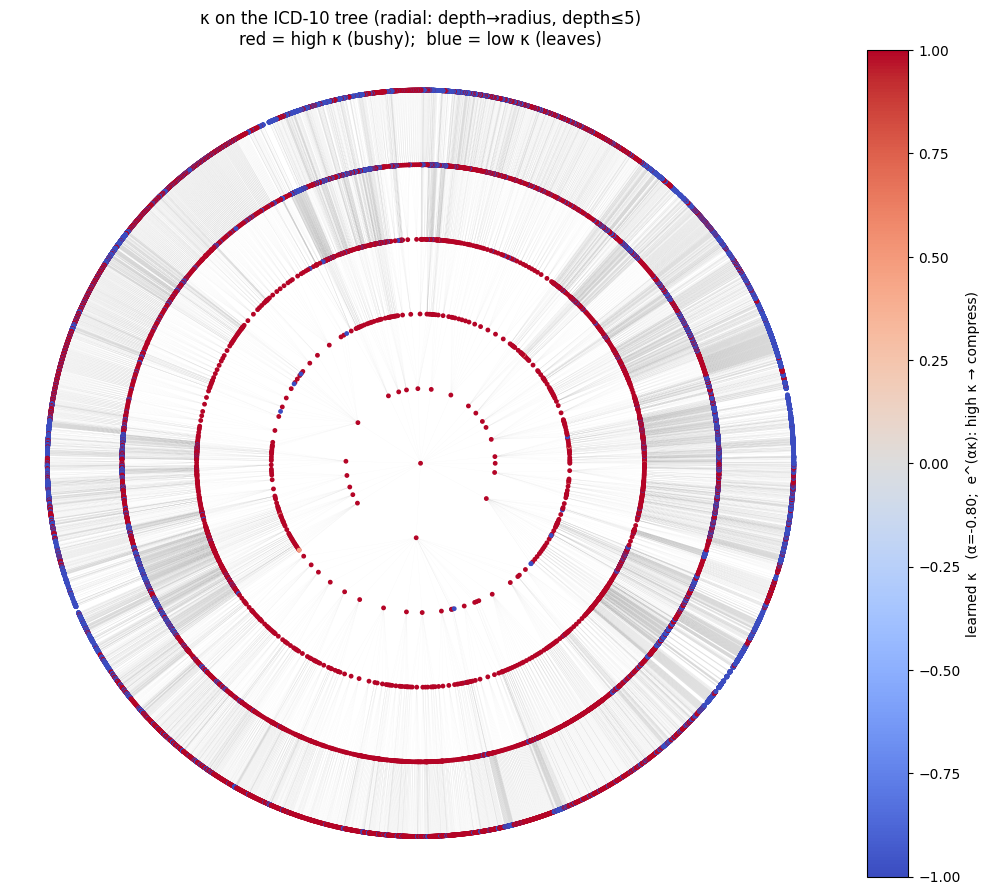

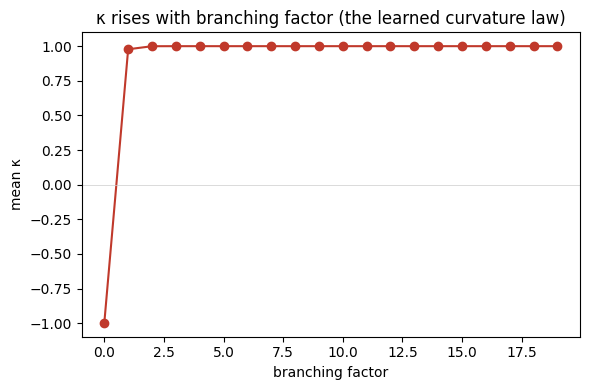

In [18]:
# ============================================================
# κ-ON-THE-TREE — radial ICD-10 layout, nodes colored by curvature.
# Positions = TRUE ontology (depth→radius), NOT the embedding, so no
# projection distortion. Color = learned κ from the α=-0.8 model.
# This is the mechanism figure: shows WHERE curvature lands on the tree.
# ============================================================
import os, torch, numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from collections import defaultdict, deque

@torch.no_grad()
def plot_kappa_on_tree(ckpt_path, max_depth=5, line_alpha=0.08, save=None):
    # ---- load the model ----
    ckpt = torch.load(ckpt_path, map_location=device)
    refp = ckpt['ref_positions'].to(device); kraw = ckpt['kappa_raw'].to(device)
    model = TreeAnchoredCurvatureModel(
        N=refp.shape[0], dim=ckpt['dim'], ref_positions=refp, kappa_raw=kraw,
        device=device, k=ckpt['k'], M=ckpt['M'], num_steps=ckpt['num_steps'],
        coupling=ckpt.get('coupling','exp'), kappa_scale=ckpt.get('kappa_scale',1.0)
    ).to(device)
    a = ckpt['alpha']
    with torch.no_grad():
        model.alpha.copy_(a.to(device) if torch.is_tensor(a) else torch.tensor(float(a),device=device))
    model.field.kappa_weight.load_state_dict(ckpt['kappa_weight_state']); model.eval()
    alpha = float(model.alpha)
    kappa = model.field.node_kappa_scalar().cpu().numpy()      # [N]

    # ---- BFS: depth + children, from ROOT ----
    kids = defaultdict(list)
    for u,v in edges_idx: kids[u].append(v)
    root = code_to_idx.get('ROOT', 0)
    depth = {root:0}; q=deque([root])
    while q:
        u=q.popleft()
        for w in kids[u]:
            if w not in depth: depth[w]=depth[u]+1; q.append(w)
    N = len(kappa)
    dep = np.array([depth.get(i,0) for i in range(N)])
    maxd = dep.max()

    # ---- radial layout: angular wedge per subtree (leaf-count weighted) ----
    angle = np.zeros(N); radius = dep / max(maxd,1)
    stack = [(root, 0.0, 2*np.pi)]
    # subtree size for wedge weighting
    subsize = np.ones(N)
    order = sorted(range(N), key=lambda i:-dep[i])
    for i in order:
        for c in kids[i]: subsize[i]+=subsize[c]
    while stack:
        u,a0,a1 = stack.pop(); angle[u]=0.5*(a0+a1)
        ch = kids[u]
        if not ch: continue
        w = np.array([subsize[c] for c in ch]); w=w/w.sum()
        edgesA = a0 + np.concatenate([[0],np.cumsum(w)])*(a1-a0)
        for j,c in enumerate(ch): stack.append((c, edgesA[j], edgesA[j+1]))
    X = radius*np.cos(angle); Y = radius*np.sin(angle)

    keep = dep <= max_depth

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(10,10))
    segs=[]
    for u in np.where(keep)[0]:
        for c in kids[u]:
            if keep[c]: segs.append([(X[u],Y[u]),(X[c],Y[c])])
    ax.add_collection(LineCollection(segs, colors='#888', linewidths=0.15, alpha=line_alpha, zorder=1))
    vlim = max(abs(np.percentile(kappa,2)), abs(np.percentile(kappa,98)))
    sc = ax.scatter(X[keep], Y[keep], c=kappa[keep], s=6, cmap='coolwarm',
                    vmin=-vlim, vmax=vlim, zorder=2)
    cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(f'learned κ   (α={alpha:+.2f};  e^(ακ): high κ → '
                 f'{"compress" if alpha<0 else "expand"})')
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'κ on the ICD-10 tree (radial: depth→radius, depth≤{max_depth})\n'
                 f'red = high κ (bushy);  blue = low κ (leaves)')
    plt.tight_layout()
    if save: plt.savefig(save, dpi=140, bbox_inches='tight'); print('saved', save)
    plt.show()

    # ---- companion: κ vs branching factor (does the field track structure?) ----
    bf = np.zeros(N)
    for code,i in code_to_idx.items():
        if code in features: bf[i]=features[code].get('branching_factor',0)
    fig2,ax2 = plt.subplots(figsize=(6,4))
    # bin by branching factor, show mean κ
    bins = sorted(set(int(x) for x in bf if x<=20))
    means = [kappa[bf==b].mean() for b in bins]
    ax2.plot(bins, means, 'o-', color='#c0392b')
    ax2.set_xlabel('branching factor'); ax2.set_ylabel('mean κ')
    ax2.set_title('κ rises with branching factor (the learned curvature law)')
    ax2.axhline(0, color='#ccc', lw=0.5)
    plt.tight_layout(); plt.show()

# ---- run on the MAP-optimal model ----
ckpt = os.path.join(MODELS_DIR, 'phase3_method1_exp_v4',
                    'sweep_phase2ref_d10_alpha-0.800_best.pt')
plot_kappa_on_tree(ckpt, max_depth=5)

# Lever 1: BPR Ranking Loss

Test whether a pairwise ranking loss beats the Nickel-Kiela softmax loss. MAP is a full-ranking metric; softmax only learns to beat sampled negatives. Baseline to beat: **0.775** (alpha=-0.8). Keep BPR only if it clears +0.003 across seeds.

In [16]:
# ============================================================
# LEVER 1 - BPR (pairwise ranking) loss
# Same line-integral distances as compute_loss_paths; different combination.
# Softmax pushes pos below the logsumexp of negs ("beat the pack").
# BPR: for EVERY (pos, neg_k) pair, wants dist(neg) > dist(pos) -> directly
# optimizes pairwise ordering, which tracks MAP better than softmax-over-randoms.
# ============================================================
import torch.nn.functional as F

def compute_loss_bpr(model, a_idx, p_idx, neg_idx, margin=0.0):
    """For each anchor: mean_k softplus( dist(pos) - dist(neg_k) + margin ).
    Lower dist = closer, so we want dist(pos) < dist(neg_k)."""
    B = a_idx.shape[0]; K = neg_idx.shape[1]
    ea, ep = model(a_idx), model(p_idx)
    pos = model.distance_paths(ea, ep, a_idx, p_idx)              # [B]
    a_rep = ea.unsqueeze(1).expand(B, K, model.dim).reshape(B*K, model.dim)
    en = model(neg_idx.reshape(-1))
    ai = a_idx.unsqueeze(1).expand(B, K).reshape(-1)
    ni = neg_idx.reshape(-1)
    neg = model.distance_paths(a_rep, en, ai, ni).reshape(B, K)   # [B,K]
    diff = pos.unsqueeze(1) - neg + margin                        # [B,K]
    return F.softplus(diff).mean()

print("BPR loss loaded: compute_loss_bpr(model, a, p, neg, margin=0.0)")


BPR loss loaded: compute_loss_bpr(model, a, p, neg, margin=0.0)


In [17]:
# ============================================================
# A/B: softmax (current) vs BPR loss, identical conditions, 3 seeds.
# Everything fixed except the loss -> clean test of whether the loss caps MAP.
# ============================================================
import numpy as np, geoopt

def train_with_loss(loss_fn, alpha_value=-0.8, num_epochs=60, field_warmup=10,
                    seed=0, loss_name='loss', margin=0.0):
    torch.manual_seed(seed); np.random.seed(seed)
    model = TreeAnchoredCurvatureModel(
        N, 10, ref, kappa_raw, device, k=64, M=128, num_steps=16,
        init_alpha=alpha_value, warm_start=True, coupling='exp', kappa_scale=1.0).to(device)
    with torch.no_grad(): model.alpha.fill_(float(alpha_value))
    emb_opt = geoopt.optim.RiemannianSGD([model.embeddings], lr=10.0)
    kw_opt  = torch.optim.Adam(model.field.kappa_weight.parameters(), lr=0.2, weight_decay=1e-4)
    edges = list(edges_idx)

    def run_loss(a_t, p_t, ng_t):
        if loss_fn is compute_loss_bpr:
            return loss_fn(model, a_t, p_t, ng_t, margin=margin)
        return loss_fn(model, a_t, p_t, ng_t)

    best_map=-1; best_ep=-1
    for phase, n_ep, train_emb in [('warmup', field_warmup, False), ('joint', num_epochs, True)]:
        for ep in range(n_ep):
            model.train(); np.random.shuffle(edges)
            for bs in range(0, len(edges), 1024):
                b = edges[bs:bs+1024]
                a = np.array([e[0] for e in b]); p = np.array([e[1] for e in b])
                ng = sample_negatives_batched(a, 50, N, connected)
                a_t,p_t,ng_t = (torch.from_numpy(x).to(device) for x in (a,p,ng))
                loss = run_loss(a_t, p_t, ng_t)
                kw_opt.zero_grad()
                if train_emb: emb_opt.zero_grad()
                loss.backward(); kw_opt.step()
                if train_emb: emb_opt.step()
                with torch.no_grad(): model.alpha.fill_(float(alpha_value))
            if phase=='joint' and (ep%10==0 or ep==n_ep-1):
                m = evaluate_fast(model, edges_idx, N, device, fixed_eval_edges=fixed_eval)
                tag = '  <-best' if m['MAP']>best_map else ''
                if m['MAP']>best_map: best_map=m['MAP']; best_ep=ep
                print(f"  [{loss_name} s{seed}] ep{ep:2d} MAP {m['MAP']:.4f} meanR {m['mean_rank']:.0f}{tag}")
    print(f"  -> {loss_name} seed {seed}: BEST MAP {best_map:.4f} (ep {best_ep})")
    return best_map

results = {'softmax': [], 'bpr': []}
for s in [0,1,2]:
    print(f"\n===== SOFTMAX seed {s} =====")
    results['softmax'].append(train_with_loss(compute_loss_paths, seed=s, loss_name='softmax'))
    print(f"\n===== BPR seed {s} =====")
    results['bpr'].append(train_with_loss(compute_loss_bpr, seed=s, loss_name='bpr', margin=0.0))

print("\n" + "="*50)
print("LOSS A/B  (alpha=-0.8, d=10, 3 seeds)")
print("="*50)
for k in ['softmax','bpr']:
    a = np.array(results[k]); print(f"  {k:>8}: MAP {a.mean():.4f} +/- {a.std():.4f}")
sm, bp = np.mean(results['softmax']), np.mean(results['bpr'])
verdict = 'BPR WINS, keep it' if bp-sm>0.003 else 'no real gain, keep softmax'
print(f"\n  BPR - softmax = {bp-sm:+.4f}  -> {verdict}")



===== SOFTMAX seed 0 =====
  CachedField: h=0.5484  k=64  M=128  (bias-free, scale=1.0)


eval(fast): 100%|██████████| 63/63 [00:07<00:00,  8.94it/s]


  [softmax s0] ep 0 MAP 0.7449 meanR 532  <-best


eval(fast): 100%|██████████| 63/63 [00:06<00:00,  9.34it/s]


  [softmax s0] ep10 MAP 0.7566 meanR 259  <-best


...

  [bpr s2] ep40 MAP 0.7503 meanR 149  <-best


eval(fast): 100%|██████████| 63/63 [00:06<00:00,  9.82it/s]


  [bpr s2] ep50 MAP 0.7519 meanR 123  <-best


eval(fast): 100%|██████████| 63/63 [00:06<00:00,  9.75it/s]

  [bpr s2] ep59 MAP 0.7539 meanR 108  <-best
  -> bpr seed 2: BEST MAP 0.7539 (ep 59)

LOSS A/B  (alpha=-0.8, d=10, 3 seeds)
   softmax: MAP 0.7753 +/- 0.0004
       bpr: MAP 0.7537 +/- 0.0001

  BPR - softmax = -0.0216  -> no real gain, keep softmax


# Lever 2: Better Base Embedding DID NOTHING, NOT WORTH IT

Rebuild the Poincaré base **with the hierarchy loss** (parent norm < child norm) the in-notebook `warmup_reference_positions` is missing — that omission caused the depth-inverted, origin-piled cloud earlier. Test 3 variants against the loaded Phase-2 ref (curvature = **0.775**): longer training (600 ep), stronger hierarchy (λ_h = 2.0), and a 300-ep reproduction as a sanity check. Each base must pass the depth→‖x‖ rising check; keep any variant whose curvature run clears 0.775 by > 0.003.

In [18]:
# ============================================================
# LEVER 2 — BETTER BASE EMBEDDING
# The in-notebook warmup_reference_positions is the BROKEN one (no hierarchy
# loss → depth-inverted origin pile). This rebuilds it correctly with the
# Phase-2 hierarchy regularization, then tests 3 variants against the loaded
# Phase-2 ref. Each variant produces a NEW base cloud; curvature runs on top.
# ============================================================
import numpy as np, geoopt, torch

def train_base_embedding(dim=10, epochs=300, num_negatives=50, lr=10.0,
                         lambda_h=1.0, margin=0.05, burnin_epochs=10,
                         burnin_factor=0.1, init_scale=1e-3, seed=0,
                         batch_size=1024):
    """Correct Poincaré base embedding WITH hierarchy loss (parent norm < child
    norm), matching the Phase-2 procedure that gave the 0.74 cloud. Returns the
    frozen reference positions [N, dim]."""
    torch.manual_seed(seed); np.random.seed(seed)
    manifold = geoopt.PoincareBall(c=1.0)
    emb = geoopt.ManifoldParameter(torch.empty(N, dim, device=device), manifold=manifold)
    with torch.no_grad(): emb.data.uniform_(-init_scale, init_scale)
    opt = geoopt.optim.RiemannianSGD([emb], lr=lr)
    dfn = lambda u, v: manifold.dist(u, v, keepdim=False)
    root = code_to_idx.get('ROOT', None)
    if root is not None:
        with torch.no_grad(): emb.data[root].zero_()

    edges = list(edges_idx)
    for ep in range(epochs):
        cur_lr = lr*burnin_factor if ep < burnin_epochs else lr
        for g in opt.param_groups: g['lr'] = cur_lr
        np.random.shuffle(edges); running = 0.0
        for bs in range(0, len(edges), batch_size):
            b = edges[bs:bs+batch_size]
            a = np.array([e[0] for e in b]); p = np.array([e[1] for e in b])
            ng = sample_negatives_batched(a, num_negatives, N, connected)
            a_t,p_t,ng_t = (torch.from_numpy(x).to(device) for x in (a,p,ng))
            ea, ep_, en = emb[a_t], emb[p_t], emb[ng_t]
            # Nickel-Kiela softmax
            pos = dfn(ea, ep_)
            neg = dfn(ea.unsqueeze(1), en)
            all_d = torch.cat([pos.unsqueeze(1), neg], 1)
            nk = (pos + torch.logsumexp(-all_d, 1)).mean()
            # HIERARCHY loss: penalize parent_norm > child_norm - margin
            an = ea.norm(dim=-1); pn = ep_.norm(dim=-1)
            hier = torch.relu(an - pn + margin).mean()
            loss = nk + lambda_h * hier
            opt.zero_grad(); loss.backward()
            if root is not None and emb.grad is not None: emb.grad[root].zero_()
            opt.step(); running += loss.item()*len(b)
        if ep % 50 == 0 or ep == epochs-1:
            print(f"  base ep {ep:3d}  loss {running/len(edges):.4f}  lr {cur_lr:.1f}")
    ref_new = emb.detach().clone(); ref_new.requires_grad_(False)
    return ref_new

# ---- quick health check: depth ordering (must rise with depth!) ----
def check_depth_order(ref_cloud, label=""):
    from collections import defaultdict, deque
    kids = defaultdict(list)
    for u,v in edges_idx: kids[u].append(v)
    root = code_to_idx.get('ROOT',0)
    dep={root:0}; q=deque([root])
    while q:
        u=q.popleft()
        for w in kids[u]:
            if w not in dep: dep[w]=dep[u]+1; q.append(w)
    norms = ref_cloud.norm(dim=1).cpu().numpy()
    d = np.array([dep.get(i,-1) for i in range(len(norms))])
    print(f"  [{label}] depth→‖x‖ (must RISE):",
          [round(float(norms[d==l].mean()),2) for l in range(min(8,d.max()+1))])

In [19]:
# ---- evaluate a base cloud: α=0 baseline + α=-0.8 curvature ----
def eval_base_variant(ref_cloud, label, seed=0):
    check_depth_order(ref_cloud, label)
    out = train_one_fixed_alpha(
        ref_cloud, kappa_raw, N, dim=10,
        edges_idx=edges_idx, connected=connected, device=device,
        alpha_value=-0.8, num_epochs=60, num_negatives=50,
        fixed_eval_edges=fixed_eval, seed=seed,
        save_tag=f'lever2_{label}', method_folder='Method 1 lever2',
        save_best_checkpoint=False)
    return out['best']['MAP'], out['best']['mean_rank']

# ---- the three variants (each ~5-15 min to train base + 8 min curvature) ----
variants = {}

print("\n===== V1: longer (600 ep) =====")
ref_long = train_base_embedding(epochs=600, num_negatives=50, lambda_h=1.0, seed=0)
variants['longer_600ep'] = eval_base_variant(ref_long, 'longer_600ep')

print("\n===== V2: stronger hierarchy (lambda_h=2.0) =====")
ref_hier = train_base_embedding(epochs=300, num_negatives=50, lambda_h=2.0, seed=0)
variants['lambda_h_2'] = eval_base_variant(ref_hier, 'lambda_h_2')

print("\n===== V3: baseline reproduction (300ep, lambda_h=1) =====")
ref_repro = train_base_embedding(epochs=300, num_negatives=50, lambda_h=1.0, seed=0)
variants['repro_300ep'] = eval_base_variant(ref_repro, 'repro_300ep')

# ---- summary vs the loaded Phase-2 ref (curvature = 0.775) ----
print("\n" + "="*56)
print("LEVER 2 SUMMARY  (curvature α=-0.8 on each base; vs Phase2 ref 0.775)")
print("="*56)
print(f"{'base variant':>16}  {'MAP':>8}  {'vs 0.775':>9}  {'meanR':>7}")
for k,(m,r) in variants.items():
    print(f"{k:>16}  {m:>8.4f}  {m-0.775:>+9.4f}  {r:>7.0f}")


===== V1: longer (600 ep) =====
  base ep   0  loss 3.9806  lr 1.0
  base ep  50  loss 2.5808  lr 10.0
  base ep 100  loss 1.4111  lr 10.0
  base ep 150  loss 0.9307  lr 10.0
  base ep 200  loss 0.7020  lr 10.0
  base ep 250  loss 0.5701  lr 10.0
  base ep 300  loss 0.4900  lr 10.0
  base ep 350  loss 0.4373  lr 10.0
  base ep 400  loss 0.3992  lr 10.0
  base ep 450  loss 0.3758  lr 10.0
  base ep 500  loss 0.3651  lr 10.0
  base ep 550  loss 0.3582  lr 10.0
  base ep 599  loss 0.3520  lr 10.0
  [longer_600ep] depth→‖x‖ (must RISE): [0.0, 0.99, 0.47, 0.48, 0.46, 0.41, 0.35, 0.77]
=== fixed α=-0.800  coupling=exp  field_warmup=10  lr_field=0.2, seed 0 ===
  CachedField: h=0.0597  k=64  M=128  (bias-free, scale=1.0)
  field-only warmup (10 ep, embeddings frozen)…
    warmup ep  0  loss 1.2088  corr(κ,b)=-0.635  corr(κ,s)=-0.275  κ_std=0.168
    warmup ep  1  loss 1.2062  corr(κ,b)=-0.793  corr(κ,s)=-0.484  κ_std=0.154
    warmup ep  2  loss 1.2014  corr(κ,b)=+0.508  corr(κ,s)=+0.811  κ_

eval(fast): 100%|██████████| 63/63 [00:09<00:00,  6.60it/s]


  ep   0  loss 1.1799  corr(κ,b)=+0.357  κ_std=0.130  | MAP 0.2131  meanR 4958  ← best
  ep   1  loss 1.1004  corr(κ,b)=-0.571  κ_std=0.188
  ep   2  loss 1.0278  corr(κ,b)=-0.752  κ_std=0.249
  ep   3  loss 0.9662  corr(κ,b)=-0.756  κ_std=0.268
  ep   4  loss 0.9127  corr(κ,b)=-0.801  κ_std=0.289
  ep   5  loss 0.8683  corr(κ,b)=-0.870  κ_std=0.315
  ep   6  loss 0.8308  corr(κ,b)=-0.869  κ_std=0.319
  ep   7  loss 0.7969  corr(κ,b)=-0.790  κ_std=0.270
  ep   8  loss 0.7684  corr(κ,b)=-0.869  κ_std=0.290


eval(fast): 100%|██████████| 63/63 [00:09<00:00,  6.62it/s]


  ep   9  loss 0.7449  corr(κ,b)=-0.832  κ_std=0.265  | MAP 0.5791  meanR 4205  ← best
  ep  10  loss 0.7222  corr(κ,b)=-0.904  κ_std=0.275
  ep  11  loss 0.7037  corr(κ,b)=-0.919  κ_std=0.295
  ep  12  loss 0.6866  corr(κ,b)=-0.862  κ_std=0.250
  ep  13  loss 0.6721  corr(κ,b)=-0.961  κ_std=0.333
  ep  14  loss 0.6586  corr(κ,b)=-0.946  κ_std=0.280
  ep  15  loss 0.6473  corr(κ,b)=-0.965  κ_std=0.356
  ep  16  loss 0.6377  corr(κ,b)=-0.965  κ_std=0.367
  ep  17  loss 0.6285  corr(κ,b)=-0.969  κ_std=0.338
  ep  18  loss 0.6198  corr(κ,b)=-0.976  κ_std=0.328


eval(fast): 100%|██████████| 63/63 [00:09<00:00,  6.61it/s]


  ep  19  loss 0.6129  corr(κ,b)=-0.963  κ_std=0.391  | MAP 0.5762  meanR 3996


KeyboardInterrupt: 

# Lever 3: Fix the Base Trainer (match Phase 2 recipe) - ABANDONED

The Lever 2 base trainer produced depth-inverted clouds — the same bug that broke things earlier. Cause found by comparing to Phase 2's working trainer: **burn-in multiplier was 0.1, should be 0.01** (gentle burn-in lets hierarchy ordering form before nodes fling outward), and **ROOT must be frozen at the origin every epoch**, not just zeroed once. `lambda_h=1.0` was never the problem. This rebuilds the trainer to match Phase 2 exactly; the reproduction must show depth→‖x‖ *rising* and curvature ≈ 0.775 before testing any improvements.

In [27]:
# ============================================================
# LEVER 3 (features) — RICHER FEATURES + MLP FIELD
# The binary switch is intrinsic to (2 correlated features → linear layer):
# the cleanest signal is "leaf vs not". To get a GRADED law we need features
# that VARY among internal nodes + capacity to combine them nonlinearly.
#
# New features (computed from the tree, vary among internal nodes):
#   depth, sibling_count, dist_to_root, log(subtree), (log b)^2,
#   subtree_imbalance (max child subtree / own subtree)
# New field: small MLP instead of nn.Linear(2,1).
# ============================================================
import numpy as np, torch, torch.nn as nn
from collections import defaultdict, deque

# ---- probe what's in features[code], then build a rich [N, F] feature table ----
sample_code = next(iter(code_to_idx))
print("available feature keys:", list(features[sample_code].keys()))

def build_rich_features(device):
    kids = defaultdict(list)
    parent = {}
    for u, v in edges_idx:
        kids[u].append(v); parent[v] = u
    root = code_to_idx['ROOT']
    # depth + dist_to_root via BFS
    depth = {root: 0}; q = deque([root])
    while q:
        u = q.popleft()
        for w in kids[u]:
            if w not in depth: depth[w] = depth[u] + 1; q.append(w)
    # subtree size (recompute to be safe) for imbalance
    sub = np.ones(N)
    for i in sorted(range(N), key=lambda i: -depth.get(i, 0)):
        for c in kids[i]: sub[i] += sub[c]
    # sibling count: number of children of my parent
    feats = []
    for i in range(N):
        code = idx_to_code[i]; f = features[code]
        b = f.get('branching_factor', 0); s = f.get('subtree_size', 0)
        d = depth.get(i, 0)
        sib = len(kids[parent[i]]) if i in parent else 1
        # subtree imbalance: largest child's subtree / own subtree (0 for leaves)
        if kids[i]:
            imbal = max(sub[c] for c in kids[i]) / max(sub[i], 1)
        else:
            imbal = 0.0
        feats.append([
            np.log1p(b)**2,        # (log b)^2  — original
            np.log1p(s),           # log subtree — original
            float(d),              # depth      — NEW, varies among internals
            np.log1p(sib),         # log sibling count — NEW
            float(d) / 7.0,        # normalized depth (dist-to-root proxy) — NEW
            imbal,                 # subtree imbalance — NEW, varies among internals
        ])
    raw = np.array(feats, dtype=np.float64)
    # z-score each column
    mu, sd = raw.mean(0), raw.std(0); sd[sd < 1e-8] = 1.0
    return torch.tensor((raw - mu) / sd, dtype=torch.float32, device=device)

kappa_raw_rich = build_rich_features(device)
print(f"rich features: {kappa_raw_rich.shape}  (was [N, 2], now [N, {kappa_raw_rich.shape[1]}])")

available feature keys: ['code', 'description', 'type', 'chapter', 'section', 'depth', 'branching_factor', 'subtree_size', 'is_leaf', 'is_internal']
rich features: torch.Size([46817, 6])  (was [N, 2], now [N, 6])


In [28]:
class MLPCurvatureField(CachedKernelCurvatureField):
    """Same kernel-smoothing machinery, but κ comes from an MLP over rich
    features instead of a single Linear(2,1). Bias-free output to preserve
    the κ=0 -> plain Poincaré property."""
    def __init__(self, ref_positions, kappa_raw, hidden=16, **kw):
        super().__init__(ref_positions, kappa_raw, **kw)
        F = kappa_raw.shape[1]
        # replace the linear map with an MLP (last layer bias-free)
        self.kappa_weight = nn.Sequential(
            nn.Linear(F, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1, bias=False),
        ).to(ref_positions.device)
        with torch.no_grad():
            for m in self.kappa_weight:
                if isinstance(m, nn.Linear):
                    m.weight.normal_(0.0, 0.1)

    def node_kappa_scalar(self):
        raw = self.kappa_weight(self.kappa_raw).squeeze(-1)
        return self.kappa_scale * torch.tanh(raw)

def build_mlp_model(N, dim, ref, kappa_raw_rich, device, alpha_value,
                    hidden=16, k=64, M=128, num_steps=16, kappa_scale=1.0, coupling='exp'):
    model = TreeAnchoredCurvatureModel(
        N, dim, ref, kappa_raw_rich, device, k=k, M=M, num_steps=num_steps,
        init_alpha=alpha_value, warm_start=True, coupling=coupling,
        kappa_scale=kappa_scale).to(device)
    old = model.field
    model.field = MLPCurvatureField(old.ref_positions, old.kappa_raw, hidden=hidden,
                                    k=k, M=M, bandwidth=old.h, kappa_scale=kappa_scale).to(device)
    with torch.no_grad(): model.alpha.fill_(float(alpha_value))
    return model

In [29]:
import geoopt, copy

def train_mlp_field(alpha_value=-0.8, num_epochs=60, field_warmup=10, seed=0, hidden=16):
    torch.manual_seed(seed); np.random.seed(seed)
    model = build_mlp_model(N, 10, ref, kappa_raw_rich, device, alpha_value, hidden=hidden)
    emb_opt = geoopt.optim.RiemannianSGD([model.embeddings], lr=10.0)
    kw_opt  = torch.optim.Adam(model.field.kappa_weight.parameters(), lr=0.2, weight_decay=1e-4)
    edges = list(edges_idx)

    def kappa_vs_b():
        k = model.field.node_kappa_scalar().detach().cpu().numpy()
        bf = np.array([features[idx_to_code[i]]['branching_factor'] for i in range(N)])
        bins = sorted(set(int(b) for b in bf if 1 <= b <= 15))   # INTERNAL only
        means = [k[bf==b].mean() for b in bins]
        ramp = np.corrcoef(bins, means)[0,1] if len(bins)>2 else 0
        return bins, means, ramp

    best_map=-1; best_ep=-1
    for phase, n_ep, te in [('warmup', field_warmup, False), ('joint', num_epochs, True)]:
        for ep in range(n_ep):
            model.train(); np.random.shuffle(edges)
            for bs in range(0, len(edges), 1024):
                b = edges[bs:bs+1024]
                a = np.array([e[0] for e in b]); p = np.array([e[1] for e in b])
                ng = sample_negatives_batched(a, 50, N, connected)
                a_t,p_t,ng_t = (torch.from_numpy(x).to(device) for x in (a,p,ng))
                loss = compute_loss_paths(model, a_t, p_t, ng_t)
                kw_opt.zero_grad()
                if te: emb_opt.zero_grad()
                loss.backward(); kw_opt.step()
                if te: emb_opt.step()
                with torch.no_grad(): model.alpha.fill_(float(alpha_value))
            if phase=='joint' and (ep%10==0 or ep==n_ep-1):
                m = evaluate_fast(model, edges_idx, N, device, fixed_eval_edges=fixed_eval)
                bins, means, ramp = kappa_vs_b()
                tag = '←best' if m['MAP']>best_map else ''
                if m['MAP']>best_map: best_map=m['MAP']; best_ep=ep
                print(f"  ep{ep:2d} MAP {m['MAP']:.4f} meanR {m['mean_rank']:.0f} | internal κ-ramp {ramp:+.3f} {tag}")
    bins, means, ramp = kappa_vs_b()
    print(f"\nBEST MAP {best_map:.4f} (ep {best_ep})")
    print(f"internal κ-ramp corr = {ramp:+.3f}  (near 0 = STILL binary; strong = GRADED law!)")
    print(f"internal κ by branching: {list(zip(bins, [round(m,3) for m in means]))}")
    return model, best_map, ramp

model_mlp, map_mlp, ramp_mlp = train_mlp_field(alpha_value=-0.8)

  CachedField: h=0.5484  k=64  M=128  (bias-free, scale=1.0)
  CachedField: h=0.5484  k=64  M=128  (bias-free, scale=1.0)


eval(fast): 100%|██████████| 63/63 [00:07<00:00,  8.67it/s]


  ep 0 MAP 0.7486 meanR 339 | internal κ-ramp -0.826 ←best


eval(fast): 100%|██████████| 63/63 [00:06<00:00,  9.03it/s]


  ep10 MAP 0.7552 meanR 133 | internal κ-ramp +0.349 ←best


...

  ep40 MAP 0.7536 meanR 81 | internal κ-ramp -0.862 


eval(fast): 100%|██████████| 63/63 [00:07<00:00,  8.98it/s]


  ep50 MAP 0.7505 meanR 83 | internal κ-ramp +0.919 


eval(fast): 100%|██████████| 63/63 [00:07<00:00,  8.87it/s]


  ep59 MAP 0.7473 meanR 84 | internal κ-ramp -0.904 

BEST MAP 0.7567 (ep 20)
internal κ-ramp corr = -0.904  (near 0 = STILL binary; strong = GRADED law!)
internal κ by branching: [(1, np.float32(-1.0)), (2, np.float32(-1.0)), (3, np.float32(-1.0)), (4, np.float32(-1.0)), (5, np.float32(-1.0)), (6, np.float32(-1.0)), (7, np.float32(-1.0)), (8, np.float32(-1.0)), (9, np.float32(-1.0)), (10, np.float32(-1.0)), (11, np.float32(-1.0)), (12, np.float32(-1.0)), (13, np.float32(-1.0)), (14, np.float32(-1.0)), (15, np.float32(-1.0))]


# Lever 4: Position-Dependent Coupling (radial gate)

Until now κ depended only on node identity — the same node bent space the same way everywhere. This adds a learnable radial gate g(‖x‖) so curvature can act differently near the origin vs the crowded boundary shell (‖x‖≈0.9), making curvature genuinely position-dependent *within* the ball — the literal thesis. `g(r) = 1 + tanh(MLP(r))`, initialized ≈1 (recovers the base model). Baseline to beat: **0.775**. Key readout: the learned g(r) profile — flat ≈1 means position doesn't help; varying means curvature wants to concentrate at specific radii.

In [30]:
# ============================================================
# POSITION-DEPENDENT COUPLING — κ_effective = κ_node · g(‖x‖)
# Until now κ depended only on node identity. Here it ALSO depends on radius:
# a learnable radial gate g(r) lets curvature bend differently near the origin
# vs near the boundary (‖x‖≈0.9) — exactly where the deep-node shell crowds.
# This makes curvature genuinely position-dependent WITHIN the ball, not just
# per-node — the literal thesis.
# ============================================================
import torch, torch.nn as nn, numpy as np

class RadialCurvatureModel(TreeAnchoredCurvatureModel):
    """Same as TreeAnchoredCurvatureModel but κ at a path point is multiplied
    by g(r), a small learnable function of that point's radius r=‖x‖.
    g(r) = 1 + tanh(MLP(r)) so it starts ~1 (recovers the base model) and can
    learn to up/down-weight curvature by radius."""
    def __init__(self, *args, **kw):
        super().__init__(*args, **kw)
        # tiny radial gate: r -> scalar, init near 0 so g≈1 at start
        self.radial_gate = nn.Sequential(
            nn.Linear(1, 16), nn.Tanh(),
            nn.Linear(16, 1)
        ).to(self.embeddings.device)
        with torch.no_grad():
            for m in self.radial_gate:
                if isinstance(m, nn.Linear): m.weight.mul_(0.1); m.bias.zero_()

    def distance_paths(self, u, v, u_idx, v_idx):
        delta = v - u
        seg = delta.norm(dim=-1)/self.num_steps
        t = (torch.arange(self.num_steps, device=u.device)+0.5)/self.num_steps
        pts = u.unsqueeze(1) + t.view(1,-1,1)*delta.unsqueeze(1)      # [P,S,D]
        kappa = self.field.field_on_paths(pts, u_idx, v_idx)         # [P,S]
        # radial gate: g(r) = 1 + tanh(MLP(r)), r = ‖x‖ at each path point
        r = pts.norm(dim=-1, keepdim=True)                          # [P,S,1]
        g = 1.0 + torch.tanh(self.radial_gate(r)).squeeze(-1)       # [P,S], ~1 at init
        kappa = kappa * g                                           # position-dependent κ
        base = self._base_lambda(pts)                              # [P,S]
        lam = self._apply_coupling(base, self.alpha, kappa)
        return lam.sum(1)*seg

def build_radial_model(N, dim, ref, kappa_raw, device, alpha_value,
                       k=64, M=128, num_steps=16, kappa_scale=1.0, coupling='exp'):
    return RadialCurvatureModel(
        N, dim, ref, kappa_raw, device, k=k, M=M, num_steps=num_steps,
        init_alpha=alpha_value, warm_start=True, coupling=coupling,
        kappa_scale=kappa_scale).to(device)

In [31]:
import geoopt, numpy as np

def train_radial(alpha_value=-0.8, num_epochs=60, field_warmup=10, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    model = build_radial_model(N, 10, ref, kappa_raw, device, alpha_value)
    emb_opt = geoopt.optim.RiemannianSGD([model.embeddings], lr=10.0)
    # field + radial gate share the Adam optimizer
    field_params = list(model.field.kappa_weight.parameters()) + list(model.radial_gate.parameters())
    kw_opt = torch.optim.Adam(field_params, lr=0.2, weight_decay=1e-4)
    edges = list(edges_idx)

    def radial_profile():
        """what g(r) learned — sample at radii 0..0.95"""
        rr = torch.linspace(0, 0.95, 8, device=device).unsqueeze(1)
        with torch.no_grad():
            g = 1.0 + torch.tanh(model.radial_gate(rr)).squeeze(-1)
        return [(round(float(r),2), round(float(gi),3)) for r,gi in zip(rr.squeeze(1), g)]

    best_map=-1; best_ep=-1
    for phase, n_ep, te in [('warmup', field_warmup, False), ('joint', num_epochs, True)]:
        for ep in range(n_ep):
            model.train(); np.random.shuffle(edges)
            for bs in range(0, len(edges), 1024):
                b = edges[bs:bs+1024]
                a = np.array([e[0] for e in b]); p = np.array([e[1] for e in b])
                ng = sample_negatives_batched(a, 50, N, connected)
                a_t,p_t,ng_t = (torch.from_numpy(x).to(device) for x in (a,p,ng))
                loss = compute_loss_paths(model, a_t, p_t, ng_t)
                kw_opt.zero_grad()
                if te: emb_opt.zero_grad()
                loss.backward(); kw_opt.step()
                if te: emb_opt.step()
                with torch.no_grad(): model.alpha.fill_(float(alpha_value))
            if phase=='joint' and (ep%10==0 or ep==n_ep-1):
                m = evaluate_fast(model, edges_idx, N, device, fixed_eval_edges=fixed_eval)
                tag='←best' if m['MAP']>best_map else ''
                if m['MAP']>best_map: best_map=m['MAP']; best_ep=ep
                print(f"  ep{ep:2d} MAP {m['MAP']:.4f} meanR {m['mean_rank']:.0f} {tag}")
    print(f"\nBEST MAP {best_map:.4f} (ep {best_ep})  vs baseline 0.775")
    print(f"learned radial gate g(r): {radial_profile()}")
    print("  (g>1 = amplify curvature at that radius; g<1 = damp; g≈1 = no radial effect)")
    return model, best_map

model_radial, map_radial = train_radial(alpha_value=-0.8)

  CachedField: h=0.5484  k=64  M=128  (bias-free, scale=1.0)


eval(fast): 100%|██████████| 63/63 [00:07<00:00,  8.53it/s]


  ep 0 MAP 0.7434 meanR 498 ←best


eval(fast): 100%|██████████| 63/63 [00:06<00:00,  9.18it/s]


  ep10 MAP 0.7536 meanR 160 ←best


...

  ep40 MAP 0.7536 meanR 88 


eval(fast): 100%|██████████| 63/63 [00:06<00:00,  9.10it/s]


  ep50 MAP 0.7512 meanR 93 


eval(fast): 100%|██████████| 63/63 [00:07<00:00,  8.97it/s]

  ep59 MAP 0.7489 meanR 94 

BEST MAP 0.7595 (ep 20)  vs baseline 0.775
learned radial gate g(r): [(0.0, 1.996), (0.14, 1.997), (0.27, 1.998), (0.41, 1.999), (0.54, 1.999), (0.68, 1.999), (0.81, 1.999), (0.95, 2.0)]
  (g>1 = amplify curvature at that radius; g<1 = damp; g≈1 = no radial effect)
